In [1]:
import sys
sys.path.insert(0, '../lib/')

In [2]:
import collections
import functools
import os
import pathlib

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.multitest
import joblib
import re

import common_data

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200
%config InlineBackend.figure_format = "retina"

In [ ]:
ROOT = common_data.DATA

In [ ]:
PADJ_CUTOFF = 0.05
class ComparisonInfo:
    def __init__(self, control, condition, genes, genes_to_keep):
        self.control = control
        self.condition = condition
        self.genes_raw = genes
        self.filter_genes(genes_to_keep)

    def filter_genes(self, genes_to_keep):
        filtered_degs = self.genes_raw.loc[self.genes_raw.index.isin(genes_to_keep), :].copy()
        filtered_degs = filtered_degs.loc[filtered_degs.padj.notna()].copy()
        # recompute FDR correction on the filtered genes:
        filtered_degs['padj'] = statsmodels.stats.multitest.fdrcorrection(
            filtered_degs.pvalue,
            alpha=PADJ_CUTOFF
        )[1]
        # recompute gene status based on new `padj`
        filtered_degs['sign'] = ''
        filtered_degs.loc[
            filtered_degs.padj.lt(PADJ_CUTOFF)
            & filtered_degs.log2FoldChange.gt(0),
            'sign'
        ] = f'Up in {self.condition}'
        filtered_degs.loc[
            filtered_degs.padj.lt(PADJ_CUTOFF)
            & filtered_degs.log2FoldChange.lt(0),
            'sign'
        ] = f'Up in {self.control}'
        self.genes = filtered_degs


class CellTypeInfo:
    def __init__(self, path, genes_to_keep):
        self.path = path
        self.comparisons = []
        self.meta = pd.read_csv(path / 'meta.csv', index_col=0)
        self.name = self.meta.cell_type.values[0]

        self.load_comparisons(genes_to_keep)

    def load_comparisons(self, genes_to_keep):
        for run in self.path.glob('**/degs.csv'):
            self.comparisons.append(
                ComparisonInfo(
                    'vap_is_cured_0',
                    'vap_is_cured_1',
                    pd.read_csv(run, index_col=0),
                    genes_to_keep[self.name]
                )
            )

    @property
    def n_comparisons(self):
        return len(self.comparisons)

In [6]:
class TaskInfo:
    def __init__(self, task):
        self.task = task
        self.info = {}

In [ ]:
data = joblib.load('12_deg_data.joblib')

In [8]:
data

{'vap_cured': <__main__.TaskInfo at 0x153710e5ff10>}

In [9]:
n_degs_plot = pd.DataFrame()
n_degs = pd.DataFrame()
for task in data.values():
    for ct in task.info.values():
        name = ct.name
        n_genes = ct.comparisons[0].genes.padj.lt(0.05).sum()
        n_degs.loc[task.task, name] = n_genes
        if n_genes > 0:
            n_genes = np.log10(n_genes)
        n_degs_plot.loc[task.task, name] = n_genes
n_degs = n_degs.T.sort_index()
n_degs_plot = n_degs_plot.T.sort_index()

In [10]:
n_degs.index = n_degs.index.str.replace(' ', '_')

In [ ]:
n_degs.T.to_csv('70_degs/13_deg_counts.csv')

In [12]:
n_degs

,vap_cured
CD4_T_cells,0.0
CD8_T_cells,0.0
Ciliated_cells,5.0
Classical_monocytes-1_CCR2,1.0
Classical_monocytes-2_IL1B,1.0
DC2,0.0
MRC1+C1QA+,0.0
MRC1+C1QA-,0.0
NUPR1+_Macs,0.0
Perivascular_macrophages,0.0


In [ ]:
BASE = ROOT / '05_pseudobulk/12_degs'

In [14]:
data['vap_cured'].task_info = common_data.TaskInfo(
    'vap_cured',
    None,
    ['not cured', 'cured'],
    None
)

In [15]:
result = {}
for _, task in data.items():
    gseas = []
    for k, ct_info in task.info.items():
        comp = ct_info.comparisons[0]
        gsea_path = BASE / task.task / k / 'gsea.csv'
        if not gsea_path.exists():
            print(f'No GSEA for {k} in {task.task}')
            continue
        gsea = pd.read_csv(gsea_path, index_col=0)
        gsea['cell_type'] = k
        gseas.append(gsea)
    result[task.task] = pd.concat(gseas)

In [16]:
result.keys()

dict_keys(['vap_cured'])

In [17]:
def process_hallmark_name(name):
    short_words = ('ACID', 'VIA', 'BETA', 'LATE', 'BILE', 'HEME')
    result = []
    words = name.split('_')
    for word in words:
        if re.search(r'\d', word) or len(word) < 5 and word not in short_words:
            result.append(word)
        else:
            result.append(word.lower())
    result = ' '.join(result)
    result = result[0].capitalize() + result[1:]
    return result

In [18]:
def plot_gsea(task_info: common_data.TaskInfo, gsea: pd.DataFrame):
    gsea['p-value'] = gsea['NOM p-value'].copy()
    idx = gsea['p-value'].eq(0)
    min_p_val = gsea['p-value'][~idx].min()
    gsea.loc[idx, 'p-value'] = min_p_val * 0.01

    print(f'P-values exactly 0: {idx.sum()}')

    gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
    gsea['-log10(padj)'] = -np.log10(gsea.padj)
    gsea['-log10(padj)'] *= np.sign(gsea.NES)
    gsea_df = gsea.pivot_table(
        index='cell_type',
        columns='Term',
        values='-log10(padj)'
    )

    gsea_df_plot = gsea_df.fillna(0).T

    rownames = gsea_df.columns.str.replace('HALLMARK_', '')

    stars = np.empty_like(gsea_df_plot, dtype=str)
    stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

    cg = sns.clustermap(
        gsea_df_plot,
        method='ward',
        figsize=(12, 14),
        dendrogram_ratio=0.1,
        cbar_pos=(0.8, 0.82, 0.08, 0.02),
        cbar_kws=dict(
            label='$-log_{10}($q-value$) \\times sign(ES)$',
            orientation='horizontal'
        ),
        xticklabels=gsea_df.index,
        yticklabels=[process_hallmark_name(x) for x in rownames],
        cmap='coolwarm',
        annot=stars,
        fmt='',
        annot_kws=dict(
            va='center_baseline',
            fontsize=16
        )
    )
    cg.ax_cbar.annotate(task_info.column_values[0], (0, 1.3), xycoords='axes fraction', ha='left')
    cg.ax_cbar.annotate(task_info.column_values[1], (1, 1.3), xycoords='axes fraction', ha='right')

    cg.ax_heatmap.collections[0].set_rasterized(True)
    cg.ax_heatmap.set_xlabel('')
    cg.ax_heatmap.set_ylabel('')

    cg.ax_heatmap.set_xticklabels(
        cg.ax_heatmap.get_xticklabels(),
        fontsize=14,
        rotation=30,
        ha='right'
    )
    trans = mpl.transforms.Affine2D().translate(8, 0)
    for t in cg.ax_heatmap.get_xticklabels():
        t.set_transform(t.get_transform() + trans)

    cg.ax_heatmap.set_yticklabels(
        cg.ax_heatmap.get_yticklabels(),
        fontsize=14,
    )

    for t in cg.ax_heatmap.texts:
        if t.get_text() == '*':
            p = t.get_position()
            t.set_position((p[0], p[1] + 0.2))

    cg.ax_col_dendrogram.figure.subplots_adjust(left=0.05, bottom=0.1, top=1, right=0.73)
    cg.ax_cbar.set_position((0.76, 0.95, 0.15, 0.01))

    cg.ax_col_dendrogram.set_title(task_info.pathname)

    cg.ax_col_dendrogram.figure.savefig(f'00_plots/32_{task_info.pathname}_gsea.pdf', dpi=300)

Starting vap_cured
P-values exactly 0: 32


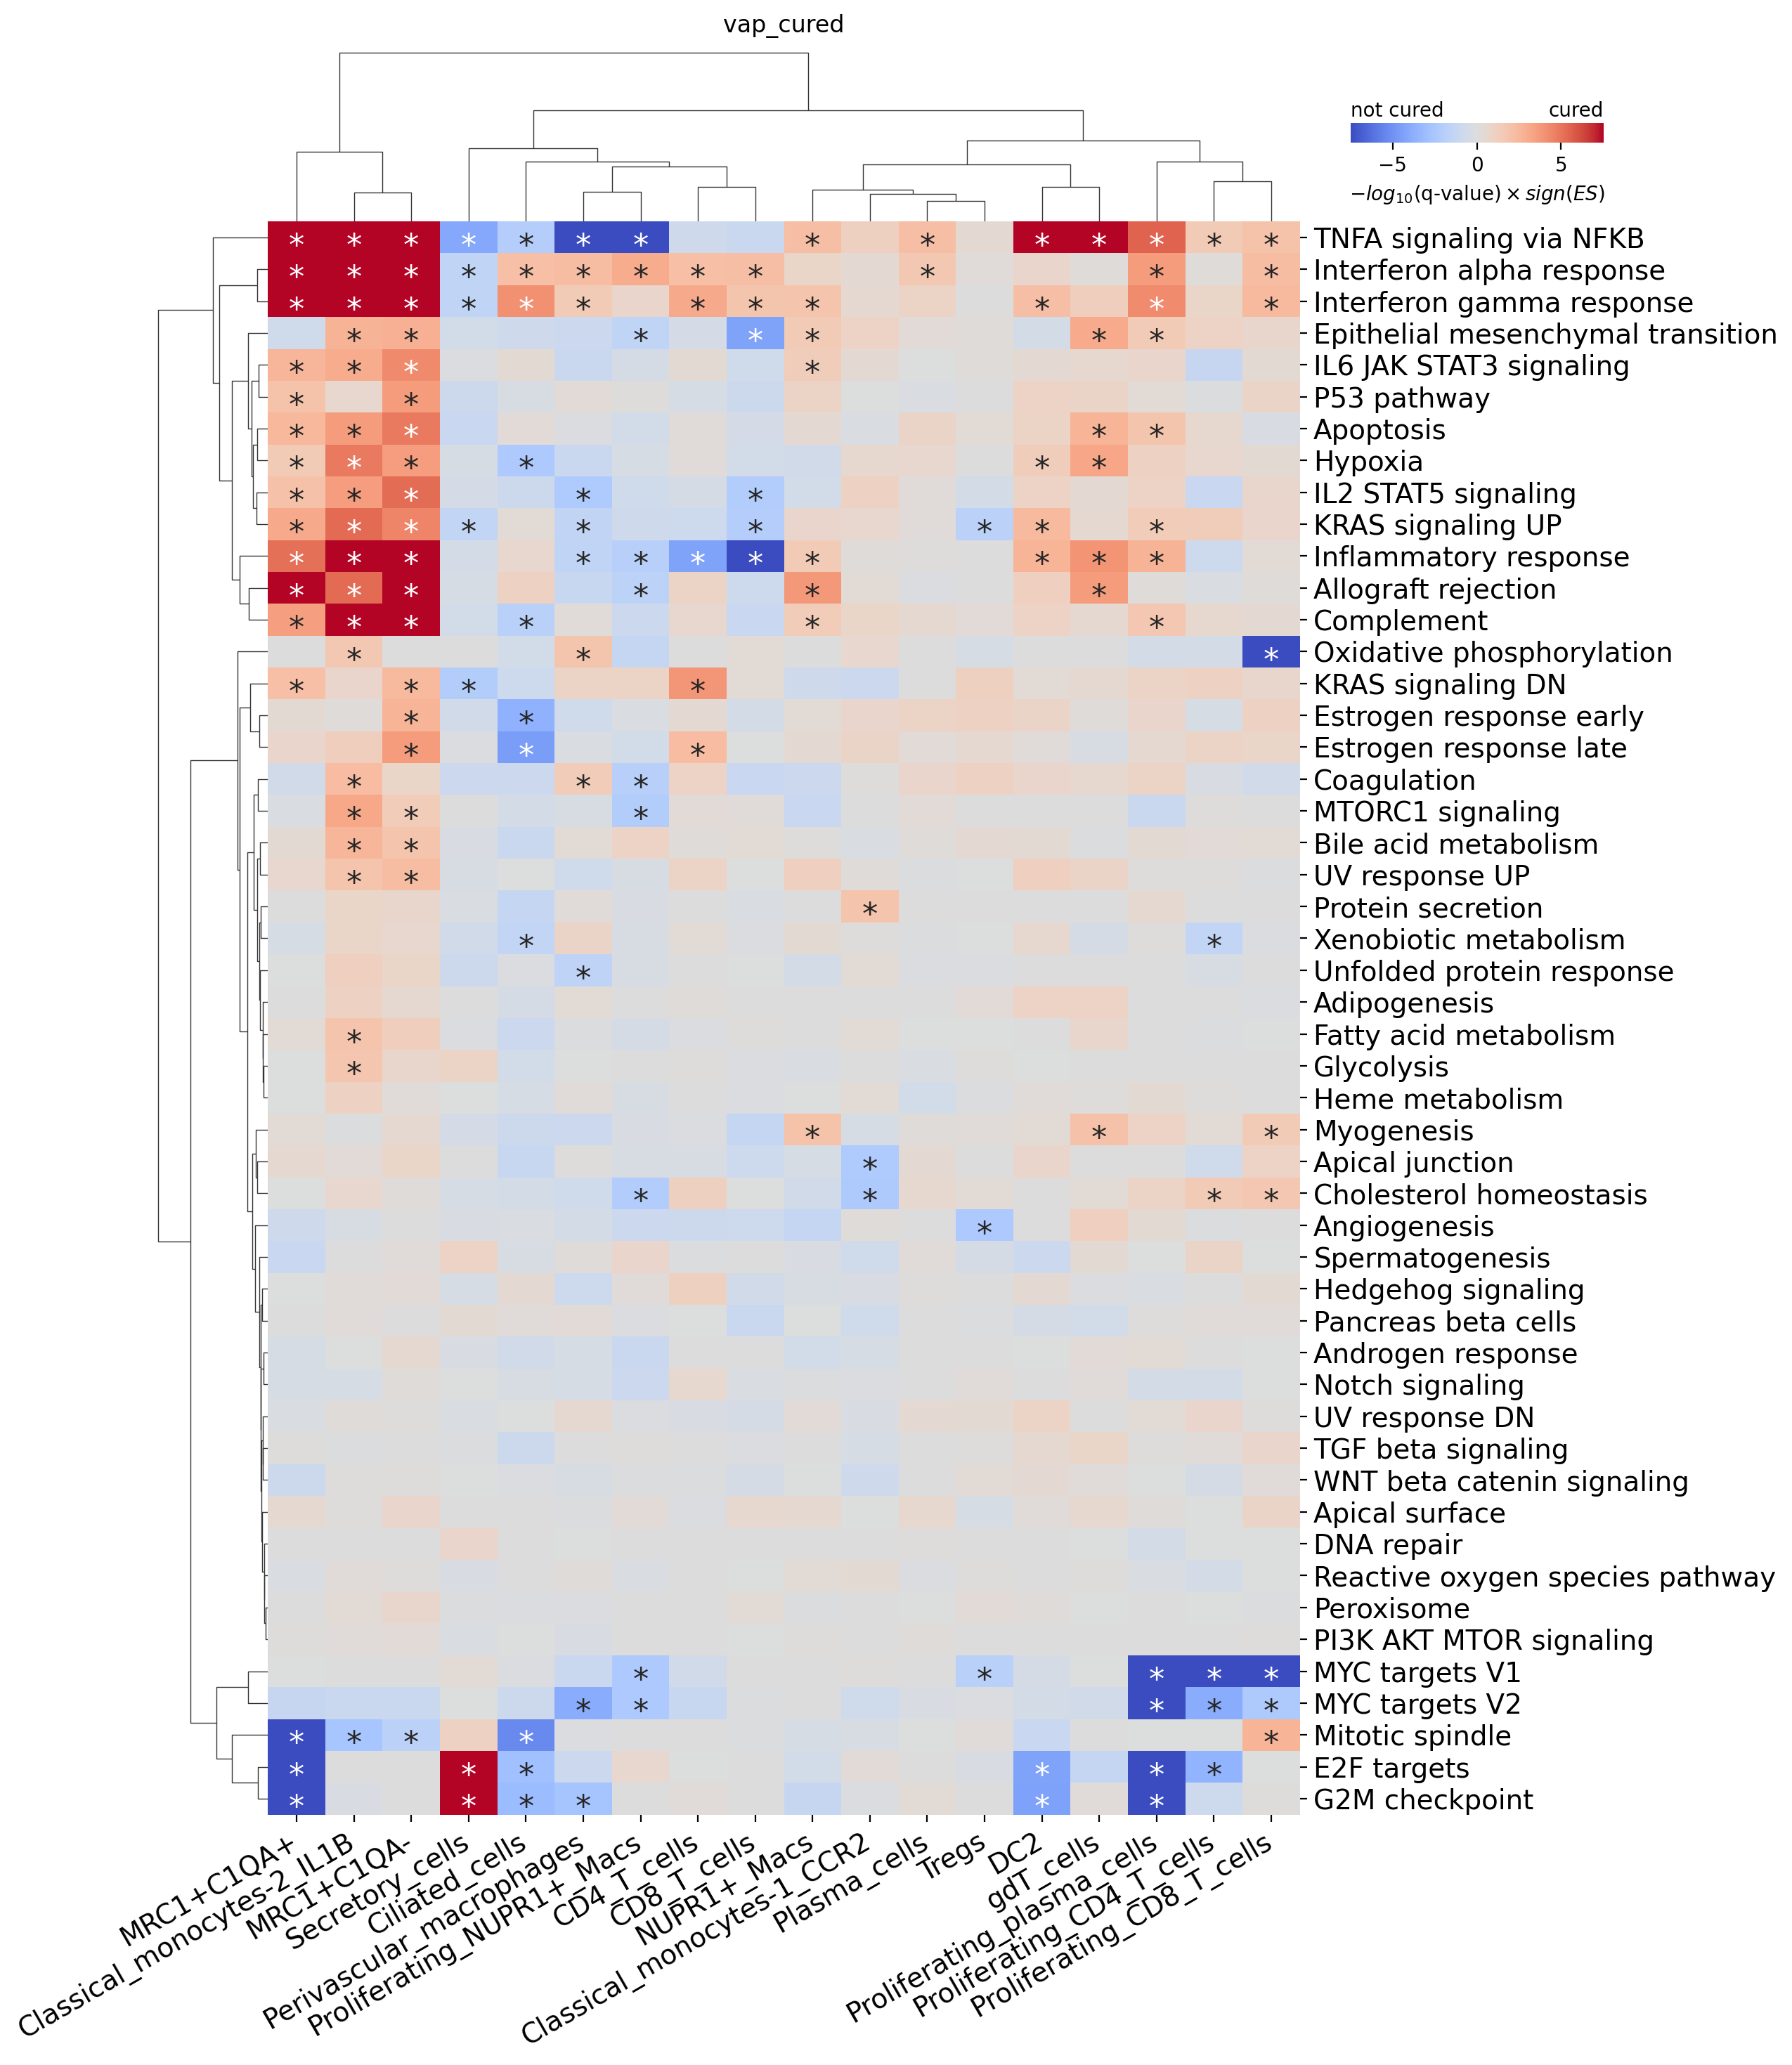

In [19]:
for d in data.values():
    print(f'Starting {d.task}')
    plot_gsea(d.task_info, result[d.task])

In [ ]:
for d in data.values():
    subdir = d.task_info.pathname
    gsea_path = f'70_degs/{subdir}_gsea.csv'
    gsea = result[d.task_info.pathname]
    gsea['p-value'] = gsea['NOM p-value'].copy()
    idx = gsea['p-value'].eq(0)
    min_p_val = gsea['p-value'][~idx].min()
    gsea.loc[idx, 'p-value'] = min_p_val * 0.01
    gsea['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea['p-value'])[1]
    gsea['-log10(padj)'] = -np.log10(gsea.padj)
    gsea['-log10(padj)'] *= np.sign(gsea.NES)
    result[d.task_info.pathname].to_csv(gsea_path)

In [21]:
secretome = pd.read_table('protein_class_Predicted.tsv')

In [ ]:
for d in data.values():
    subdir = d.task_info.pathname
    for ct in d.info.keys():
        deg_path = f'70_degs/{subdir}/{ct}_degs.csv'
        degs = d.info[ct].comparisons[0].genes
        degs['secretome'] = pd.Series(degs.index.isin(secretome.Gene)).replace(
            {True: 'Yes', False: ''}
        ).values
        degs.sign = degs.sign.str.replace('Alive', 'alive').str.replace('Dead', 'dead')
        os.makedirs(os.path.dirname(deg_path), exist_ok=True)
        degs.to_csv(deg_path)

In [ ]:
result = []
for d in data.values():
    task_info = d.task_info
    group1 = task_info.column_values[0].lower()
    group2 = task_info.column_values[1].lower()
    for ct in d.info.keys():
        meta = d.info[ct].meta
        group1_count = meta.group.astype(str).eq('0').sum()
        group2_count = meta.group.astype(str).eq('1').sum()
        discard_count = meta.group.eq('discard').sum()
        group1_up = d.info[ct].comparisons[0].genes.sign.eq(f'Up in vap_is_cured_0').sum()
        group2_up = d.info[ct].comparisons[0].genes.sign.eq(f'Up in vap_is_cured_1').sum()
        result.append(
            {
                'cell_type': ct,
                'task': task_info.pathname,
                'group1': group1,
                'group2': group2,
                'group1_count': group1_count,
                'group2_count': group2_count,
                'discard_count': discard_count,
                'group1_up': group1_up,
                'group2_up': group2_up
            }
        )
result = pd.DataFrame(result)
result.to_csv('70_degs/13_deg_stats.csv')

In [23]:
result

,cell_type,task,group1,group2,group1_count,group2_count,discard_count,group1_up,group2_up
0,CD4_T_cells,vap_cured,not cured,cured,20,18,228,0,0
1,CD8_T_cells,vap_cured,not cured,cured,19,17,242,0,0
2,Ciliated_cells,vap_cured,not cured,cured,9,5,56,2,3
3,Classical_monocytes-1_CCR2,vap_cured,not cured,cured,9,7,73,0,1
4,Classical_monocytes-2_IL1B,vap_cured,not cured,cured,20,17,201,1,0
5,DC2,vap_cured,not cured,cured,10,12,146,0,0
6,MRC1+C1QA+,vap_cured,not cured,cured,21,19,256,0,0
7,MRC1+C1QA-,vap_cured,not cured,cured,22,19,257,0,0
8,NUPR1+_Macs,vap_cured,not cured,cured,21,15,231,0,0
9,Perivascular_macrophages,vap_cured,not cured,cured,9,7,111,0,0
